# 01 · Descarga de datos — BV-BRC

**Objetivo:** Obtener desde la API pública de BV-BRC los tres recursos necesarios para el pipeline AMR:

| Recurso | Endpoint BV-BRC | Destino |
|---|---|---|
| Fenotipos AMR (etiquetas S/I/R + MIC) | `genome_amr` | `datos/brutos/amr_fenotipos.csv` |
| Genes de resistencia (presencia/ausencia) | `sp_gene` | `datos/brutos/amr_matriz_genes.csv` |
| Secuencias WGS (.fasta por genoma) | `genome_sequence` | `datos/brutos/genomas_fasta/` |

**Organismo:** *Klebsiella pneumoniae* (taxon ID: 573)  
**Antibiótico:** Ciprofloxacino  
**Objetivo de descarga:** ~500 genomas con fenotipo S o R confirmado

> ⚠️ La descarga de FASTA puede tardar 2–4 horas dependiendo de la conexión. Ejecutar con `nohup` o en sesión `tmux` si se trabaja en remoto.

---
## Celda 0 — Imports y configuración global

In [28]:
# ─── Librería estándar ────────────────────────────────────────────────────────
import os
import time
import json
import logging
from pathlib import Path
from datetime import datetime
from urllib.parse import quote

# ─── Third-party ──────────────────────────────────────────────────────────────
import requests
import pandas as pd
from tqdm.notebook import tqdm

# ─── Logging ──────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)

# ─── Rutas del proyecto ───────────────────────────────────────────────────────
ROOT        = Path.cwd().parent          # raíz del repo
DIR_BRUTOS  = ROOT / "datos" / "brutos"
DIR_FASTA   = DIR_BRUTOS / "genomas_fasta"
DIR_PROC    = ROOT / "datos" / "procesados"

for d in [DIR_BRUTOS, DIR_FASTA, DIR_PROC]:
    d.mkdir(parents=True, exist_ok=True)
    log.info(f"Directorio listo: {d}")

# ─── Parámetros de la consulta ────────────────────────────────────────────────
TAXON_ID    = "573"          # Klebsiella pneumoniae
ANTIBIOTICO = "ciprofloxacin"
MAX_GENOMAS = 600            # un poco más del objetivo para tener margen en QC

# ─── Config HTTP ──────────────────────────────────────────────────────────────
BASE_URL      = "https://www.bv-brc.org/api"
HEADERS_JSON  = {"Accept": "application/json"}
HEADERS_FASTA = {"Accept": "application/dna+fasta"}
TIMEOUT       = 60    # segundos por request
RETRY_MAX     = 3     # reintentos ante error 5xx
DELAY_FASTA   = 1.5   # segundos entre descargas FASTA (cortesía con el servidor)

print(f"Proyecto raíz : {ROOT}")
print(f"Datos brutos  : {DIR_BRUTOS}")
print(f"FASTA         : {DIR_FASTA}")
print(f"Timestamp inicio: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

12:54:39 [INFO] Directorio listo: /workspace/datos/brutos
12:54:39 [INFO] Directorio listo: /workspace/datos/brutos/genomas_fasta
12:54:39 [INFO] Directorio listo: /workspace/datos/procesados


Proyecto raíz : /workspace
Datos brutos  : /workspace/datos/brutos
FASTA         : /workspace/datos/brutos/genomas_fasta
Timestamp inicio: 2026-03-19 12:54:39


---
## Celda 1 — Función base para queries a la API (con retry)

**Fix aplicado:** `safe=" ,&+=@()"` — los paréntesis se añaden a los caracteres seguros para que
`quote()` no los codifique a `%28`/`%29`. La documentación oficial de BV-BRC especifica que los
operadores RQL deben enviarse con paréntesis literales en la URL.

In [29]:
def bvbrc_query(
    endpoint: str,
    rql: str,
    headers: dict = None,
    retries: int = RETRY_MAX,
) -> requests.Response:
    """
    GET contra BV-BRC usando RQL (Resource Query Language).

    Según la documentación oficial (https://www.bv-brc.org/api/doc/), los
    operadores RQL deben ir con paréntesis literales en la URL:

        eq(campo,valor)           → filtro exacto
        in(campo,(v1,v2,v3))      → filtro múltiple
        select(c1,c2)             → proyección de columnas
        limit(n,offset)           → paginación
        sort(+campo)              → ordenación

    Ejemplo URL válida:
        /api/genome_amr/?eq(taxon_id,573)&limit(100,0)&select(genome_id,antibiotic)

    IMPORTANTE:
    - Los params RQL van en la URL directamente, NO como dict de requests.
      requests.get(params=dict) codificaría paréntesis y rompería la query.
    - Solo se codifican los valores individuales (espacios, caracteres especiales
      dentro de los valores), nunca los operadores RQL.

    Parameters
    ----------
    endpoint : str
        Nombre del endpoint, p.ej. 'genome_amr', 'sp_gene'
    rql : str
        Query RQL completa con paréntesis literales y espacios sin codificar.
        Correcto:   'eq(property,Antibiotic Resistance)'
        Incorrecto: 'eq(property,Antibiotic%20Resistance)'  ← doble encoding
    headers : dict
        Cabeceras HTTP; por defecto JSON
    retries : int
        Número de reintentos ante errores 5xx o timeout

    Returns
    -------
    requests.Response
    """
    if headers is None:
        headers = HEADERS_JSON

    # FIX: añadir () a safe para que los paréntesis RQL no se codifiquen.
    # Solo se codifican espacios y otros caracteres especiales en los VALORES.
    # La versión anterior usaba safe=',&+=@' → paréntesis → %28/%29 → 404 en sp_gene.
    rql_encoded = quote(rql, safe=",&+=@()")
    url = f"{BASE_URL}/{endpoint}/?{rql_encoded}"

    for attempt in range(1, retries + 1):
        try:
            resp = requests.get(url, headers=headers, timeout=TIMEOUT)
            resp.raise_for_status()
            return resp
        except requests.exceptions.HTTPError as e:
            if resp.status_code < 500 or attempt == retries:
                raise
            wait = 2 ** attempt
            log.warning(f"Error {resp.status_code} — reintento {attempt}/{retries} en {wait}s")
            time.sleep(wait)
        except requests.exceptions.Timeout:
            if attempt == retries:
                raise
            log.warning(f"Timeout — reintento {attempt}/{retries}")
            time.sleep(2 ** attempt)


def test_conexion() -> bool:
    """Comprueba que la API responde antes de lanzar la descarga masiva."""
    try:
        rql  = f"eq(taxon_id,{TAXON_ID})&limit(1,0)"
        resp = bvbrc_query("genome_amr", rql=rql)
        data = resp.json()
        log.info(f"API accesible — status {resp.status_code} | registros recibidos: {len(data)}")
        return True
    except Exception as exc:
        log.error(f"API no accesible: {exc}")
        return False


assert test_conexion(), "⛔ Sin acceso a BV-BRC — revisa la conexión de red antes de continuar"

12:54:40 [INFO] API accesible — status 200 | registros recibidos: 1


---
## Celda 2 — Descarga de fenotipos AMR

Endpoint `genome_amr`: contiene las etiquetas S/I/R y los valores MIC por genoma y antibiótico.

In [30]:
CAMPOS_FENOTIPO = [
    "genome_id",
    "genome_name",
    "antibiotic",
    "resistant_phenotype",       # S / I / R
    "measurement_value",         # MIC numérico
    "measurement_unit",          # µg/mL normalmente
    "measurement_sign",          # =, <=, >=
    "laboratory_typing_method",  # MIC, disk diffusion, …
    "laboratory_typing_platform",
    "testing_standard",          # EUCAST / CLSI
]


def descargar_fenotipos(taxon_id: str, antibiotico: str, max_rows: int = 10_000) -> pd.DataFrame:
    """
    Descarga todos los registros AMR de BV-BRC para un taxón y antibiótico.
    Pagina de 1000 en 1000 usando RQL limit(n, offset).
    """
    log.info(f"Descargando fenotipos — taxon {taxon_id} | antibiótico: {antibiotico}")

    campos    = ",".join(CAMPOS_FENOTIPO)
    registros = []
    page_size = 1_000
    start     = 0

    while True:
        rql = (
            f"eq(taxon_id,{taxon_id})"
            f"&eq(antibiotic,{antibiotico})"
            f"&in(resistant_phenotype,(Susceptible,Resistant,Intermediate))"
            f"&select({campos})"
            f"&sort(+genome_id)"
            f"&limit({page_size},{start})"
        )
        resp = bvbrc_query("genome_amr", rql=rql)
        lote = resp.json()

        if not isinstance(lote, list):
            log.warning(f"Respuesta inesperada (offset {start}): {str(lote)[:200]}")
            break

        if not lote:
            break

        registros.extend(lote)
        log.info(f"  offset {start} — {len(registros)} registros acumulados")

        start += page_size
        if start >= max_rows or len(lote) < page_size:
            break

    df = pd.DataFrame(registros)
    # FIX: Forzar genome_id a str desde el inicio para evitar artefactos float→str
    if "genome_id" in df.columns:
        df["genome_id"] = df["genome_id"].astype(str)
    log.info(f"Total descargado: {len(df)} registros | {df['genome_id'].nunique()} genomas únicos")
    return df


df_fenotipos = descargar_fenotipos(TAXON_ID, ANTIBIOTICO)

# ── Guardar raw sin ningún filtro ────────────────────────────────────────────
ruta_fenotipos = DIR_BRUTOS / "amr_fenotipos.csv"
df_fenotipos.to_csv(ruta_fenotipos, index=False)
log.info(f"Guardado → {ruta_fenotipos}  ({ruta_fenotipos.stat().st_size / 1024:.1f} KB)")

df_fenotipos.head()

12:54:40 [INFO] Descargando fenotipos — taxon 573 | antibiótico: ciprofloxacin
12:54:41 [INFO]   offset 0 — 1000 registros acumulados
12:54:42 [INFO]   offset 1000 — 2000 registros acumulados
12:54:43 [INFO]   offset 2000 — 3000 registros acumulados
12:54:44 [INFO]   offset 3000 — 4000 registros acumulados
12:54:45 [INFO]   offset 4000 — 5000 registros acumulados
12:54:46 [INFO]   offset 5000 — 6000 registros acumulados
12:54:47 [INFO]   offset 6000 — 7000 registros acumulados
12:54:48 [INFO]   offset 7000 — 8000 registros acumulados
12:54:49 [INFO]   offset 8000 — 9000 registros acumulados
12:54:50 [INFO]   offset 9000 — 10000 registros acumulados
12:54:50 [INFO] Total descargado: 10000 registros | 7582 genomas únicos
12:54:50 [INFO] Guardado → /workspace/datos/brutos/amr_fenotipos.csv  (833.3 KB)


,antibiotic,resistant_phenotype,genome_id,genome_name,measurement_value,laboratory_typing_method,testing_standard,measurement_unit,measurement_sign,laboratory_typing_platform
0,ciprofloxacin,Susceptible,573.10001,Klebsiella pneumoniae strain VRCO0337,NaN,NaN,NaN,NaN,NaN,NaN
1,ciprofloxacin,Susceptible,573.10005,Klebsiella pneumoniae strain VRCO0408,NaN,NaN,NaN,NaN,NaN,NaN
2,ciprofloxacin,Susceptible,573.10008,Klebsiella pneumoniae strain VRCO0411,NaN,NaN,NaN,NaN,NaN,NaN
3,ciprofloxacin,Susceptible,573.10010,Klebsiella pneumoniae strain VRCO0412,NaN,NaN,NaN,NaN,NaN,NaN
4,ciprofloxacin,Susceptible,573.10011,Klebsiella pneumoniae strain VRCO0414,NaN,NaN,NaN,NaN,NaN,NaN


---
## Celda 3 — Inspección rápida de fenotipos y selección de genome_ids

DISTRIBUCIÓN DE FENOTIPOS
resistant_phenotype
Resistant       6472
Susceptible     3476
Intermediate      52
Name: count, dtype: int64

ESTÁNDARES DE TEST
testing_standard
CLSI                                                     2169
EUCAST                                                    164
British Society for Antimicrobial Chemotherapy (BSAC)       1
Name: count, dtype: int64

MÉTODOS DE LABORATORIO
laboratory_typing_method
Broth dilution    2338
Disk diffusion     229
Name: count, dtype: int64



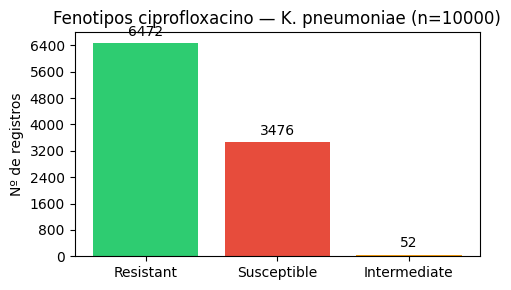

Genomas únicos S/R disponibles : 7580
resistant_phenotype
Resistant      4785
Susceptible    2795
Name: count, dtype: int64

Genomas seleccionados para descarga (estratificado): 600
resistant_phenotype
Susceptible    300
Resistant      300
Name: count, dtype: int64

Primeros 5 IDs: ['573.18536', '573.25784', '573.14995', '573.26069', '573.14962']


In [36]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Distribución de etiquetas ────────────────────────────────────────────────
print("=" * 50)
print("DISTRIBUCIÓN DE FENOTIPOS")
print("=" * 50)
print(df_fenotipos["resistant_phenotype"].value_counts())
print()

# ── Estándares de test ───────────────────────────────────────────────────────
print("ESTÁNDARES DE TEST")
if "testing_standard" in df_fenotipos.columns:
    print(df_fenotipos["testing_standard"].value_counts())
print()

# ── Métodos de laboratorio ───────────────────────────────────────────────────
print("MÉTODOS DE LABORATORIO")
if "laboratory_typing_method" in df_fenotipos.columns:
    print(df_fenotipos["laboratory_typing_method"].value_counts())
print()

# ── Plot distribución ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 3))
conteos = df_fenotipos["resistant_phenotype"].value_counts()
bars = ax.bar(conteos.index, conteos.values,
              color=["#2ecc71", "#e74c3c", "#f39c12"][:len(conteos)])
ax.bar_label(bars, padding=3)
ax.set_title(f"Fenotipos ciprofloxacino — K. pneumoniae (n={len(df_fenotipos)})")
ax.set_ylabel("Nº de registros")
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
ruta_fig = ROOT / "figuras" / "01_distribucion_fenotipos.png"
ruta_fig.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(ruta_fig, dpi=150, bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# SELECCIÓN DE GENOMAS OBJETIVO
# Nos quedamos sólo con S y R (excluimos I — intermedio — en esta fase)
# Un genoma puede tener varios registros si se testó con distintos estándares;
# priorizamos EUCAST sobre CLSI, luego tomamos el primer registro por genome_id.
# ─────────────────────────────────────────────────────────────────────────────
df_sr = df_fenotipos[df_fenotipos["resistant_phenotype"].isin(["Susceptible", "Resistant"])].copy()

orden_std = {"EUCAST": 0, "CLSI": 1}
if "testing_standard" in df_sr.columns:
    df_sr["_std_orden"] = df_sr["testing_standard"].map(orden_std).fillna(9)
    df_sr = df_sr.sort_values(["genome_id", "_std_orden"]).drop(columns="_std_orden")

df_sr_dedup = df_sr.drop_duplicates(subset="genome_id", keep="first")

print(f"Genomas únicos S/R disponibles : {len(df_sr_dedup)}")
print(df_sr_dedup["resistant_phenotype"].value_counts())

# Muestreo estratificado para no sesgar la descarga hacia S o R
# FIX: evitamos groupby().apply() porque en pandas 2.x convierte la columna
#      de agrupación en índice y luego reset_index(drop=True) la pierde.
#      Solución explícita: sample por clase y concat.
n_por_clase = min(MAX_GENOMAS // 2, df_sr_dedup["resistant_phenotype"].value_counts().min())

df_s = df_sr_dedup[df_sr_dedup["resistant_phenotype"] == "Susceptible"].sample(n=n_por_clase, random_state=42)
df_r = df_sr_dedup[df_sr_dedup["resistant_phenotype"] == "Resistant"].sample(n=n_por_clase, random_state=42)
df_seleccion = pd.concat([df_s, df_r], ignore_index=True)

# Sanity check
assert "resistant_phenotype" in df_seleccion.columns, f"Columnas: {df_seleccion.columns.tolist()}"

print(f"\nGenomas seleccionados para descarga (estratificado): {len(df_seleccion)}")
print(df_seleccion["resistant_phenotype"].value_counts())

IDS_OBJETIVO = df_seleccion["genome_id"].tolist()
print(f"\nPrimeros 5 IDs: {IDS_OBJETIVO[:5]}")

---
## Celda 4 — Descarga de matriz de genes AMR (sp_gene)

Endpoint `sp_gene` (nombre actual en BV-BRC): genes de resistencia detectados por AMRFinder/CARD en cada genoma.

**Fixes aplicados:**
- `specialty_gene` → `sp_gene` (endpoint renombrado en la API actual)
- `Antibiotic%20Resistance` → `Antibiotic Resistance` (espacio literal; `quote()` lo codifica una sola vez)
- Añadidos campos `property_source` y `antibiotics_class` disponibles en el nuevo esquema

In [32]:
# ── Celda 4 definitiva — genome_feature + keyword por familia de gen ──────────

TERMINOS_AMR = {
    # Diana primaria — varianza útil
    "gyrA"   : "GyrA",
    "gyrB"   : "GyrB",
    "parC"   : "ParC",
    "parE"   : "ParE",
    # PMQR
    "qnr"    : "quinolone resistance",
    "oqxA"   : "OqxA",
    "oqxB"   : "OqxB",
    # Modificación enzimática — fix del apóstrofe
    "aac"    : "aminoglycoside 6",
    # Porinas — alta varianza, mecanismo relevante
    "ompK35" : "OmpK35",
    "ompK36" : "OmpK36",
    # BLEEs — co-resistencia
    "blaCTX" : "CTX-M",
    "blaSHV" : "SHV",
    "blaTEM" : "TEM",
    "blaKPC" : "KPC",
    "blaNDM" : "NDM",
    "blaOXA" : "OXA",
}

CAMPOS_FEATURE = [
    "genome_id",
    "patric_id",
    "product",
    "pgfam_id",
    "plfam_id",
    "start",
    "end",
    "strand",
]


def descargar_genes_amr_feature(
    genome_ids: list[str],
    terminos: dict = TERMINOS_AMR,
    batch_size: int = 100,
) -> pd.DataFrame:
    """
    Descarga presencia de genes AMR usando genome_feature + keyword() por término.

    El campo 'gene' no está poblado en genome_feature para K. pneumoniae,
    por lo que filtramos por product usando keyword(), que busca en todos
    los campos de texto indexados.

    Una query por término × lotes de genome_ids → etiquetamos cada hit
    con su gen canónico → DataFrame largo (genome_id, gen_etiqueta, product, ...).
    """
    log.info(
        f"Descargando genes AMR (genome_feature + keyword) | "
        f"{len(genome_ids)} genomas | {len(terminos)} términos"
    )

    campos  = ",".join(CAMPOS_FEATURE)
    lotes   = [genome_ids[i:i+batch_size] for i in range(0, len(genome_ids), batch_size)]
    todos   = []

    for gen_label, termino in tqdm(terminos.items(), desc="Términos AMR"):
        registros_gen = []

        for lote in lotes:
            ids_rql = ",".join(str(gid) for gid in lote)
            rql = (
                f"in(genome_id,({ids_rql}))"
                f"&eq(feature_type,CDS)"
                f"&keyword({termino})"
                f"&select({campos})"
                f"&limit({batch_size * 10},0)"
            )
            try:
                resp  = bvbrc_query("genome_feature", rql=rql)
                datos = resp.json()
                if isinstance(datos, list):
                    for r in datos:
                        r["gen_etiqueta"] = gen_label   # ← etiquetar con nombre canónico
                    registros_gen.extend(datos)
            except Exception as e:
                log.warning(f"  Error {gen_label} / lote: {e}")
                continue

        log.info(f"  {gen_label:10s} ({termino:25s}) → {len(registros_gen)} hits")
        todos.extend(registros_gen)

    df = pd.DataFrame(todos)

    if not df.empty:
        # Un mismo gen puede aparecer varias veces por genoma (p.ej. dos copias de gyrA)
        # De momento guardamos todas las ocurrencias; en el notebook de features
        # pivotaremos a presencia/ausencia (max) o conteo según convenga.
        log.info(
            f"Total registros: {len(df)} | "
            f"genomas cubiertos: {df['genome_id'].nunique()} | "
            f"genes únicos: {df['gen_etiqueta'].nunique()}"
        )
    else:
        log.warning("Sin resultados — revisar términos o endpoint")

    return df


# ── Descarga completa ─────────────────────────────────────────────────────────
df_genes_largo = descargar_genes_amr_feature(IDS_OBJETIVO)

# ── Guardar formato largo (raw) ───────────────────────────────────────────────
ruta_genes = DIR_BRUTOS / "amr_matriz_genes.csv"
df_genes_largo.to_csv(ruta_genes, index=False)
log.info(f"Guardado → {ruta_genes}  ({ruta_genes.stat().st_size / 1024:.1f} KB)")

# ── Resumen de cobertura ──────────────────────────────────────────────────────
if not df_genes_largo.empty:
    print("\n── Hits por gen ─────────────────────────────────────────────────")
    print(df_genes_largo.groupby("gen_etiqueta")["genome_id"].nunique().sort_values(ascending=False))

    print("\n── Cobertura por genoma ─────────────────────────────────────────")
    genes_por_genoma = df_genes_largo.groupby("genome_id")["gen_etiqueta"].nunique()
    print(genes_por_genoma.describe())

    n_cero = len(IDS_OBJETIVO) - df_genes_largo["genome_id"].nunique()
    cob    = df_genes_largo["genome_id"].nunique() / len(IDS_OBJETIVO) * 100
    print(f"\n  Genomas con ≥1 gen detectado : {df_genes_largo['genome_id'].nunique()} / {len(IDS_OBJETIVO)} ({cob:.1f}%)")
    if n_cero > 0:
        print(f"  Genomas sin ningún hit       : {n_cero} → imputar con 0 en matriz de features")

12:54:51 [INFO] Descargando genes AMR (genome_feature + keyword) | 600 genomas | 16 términos


Términos AMR:   0%|          | 0/16 [00:00<?, ?it/s]

12:54:56 [INFO]   gyrA       (GyrA                     ) → 458 hits
12:55:01 [INFO]   gyrB       (GyrB                     ) → 620 hits
12:55:05 [INFO]   parC       (ParC                     ) → 610 hits
12:55:11 [INFO]   parE       (ParE                     ) → 1396 hits
12:55:15 [INFO]   qnr        (quinolone resistance     ) → 174 hits
12:55:20 [INFO]   oqxA       (OqxA                     ) → 272 hits
12:55:24 [INFO]   oqxB       (OqxB                     ) → 261 hits
12:55:29 [INFO]   aac        (aminoglycoside 6         ) → 1736 hits
12:55:34 [INFO]   ompK35     (OmpK35                   ) → 132 hits
12:55:39 [INFO]   ompK36     (OmpK36                   ) → 33 hits
12:55:43 [INFO]   blaCTX     (CTX-M                    ) → 378 hits
12:55:48 [INFO]   blaSHV     (SHV                      ) → 937 hits
12:55:53 [INFO]   blaTEM     (TEM                      ) → 441 hits
12:55:58 [INFO]   blaKPC     (KPC                      ) → 1178 hits
12:56:03 [INFO]   blaNDM     (NDM             


── Hits por gen ─────────────────────────────────────────────────
gen_etiqueta
aac       599
blaSHV    566
blaOXA    488
parE      340
gyrB      317
blaTEM    316
parC      315
blaCTX    275
gyrA      234
oqxA      163
oqxB      161
qnr       129
blaKPC    127
ompK35     90
blaNDM     44
ompK36     23
Name: genome_id, dtype: int64

── Cobertura por genoma ─────────────────────────────────────────
count    599.000000
mean       6.989983
std        2.907705
min        1.000000
25%        5.000000
50%        7.000000
75%        9.000000
max       15.000000
Name: gen_etiqueta, dtype: float64

  Genomas con ≥1 gen detectado : 599 / 600 (99.8%)
  Genomas sin ningún hit       : 1 → imputar con 0 en matriz de features


---
## Celda 5 — Descarga de secuencias FASTA

> ⏱️ Esta es la celda más lenta. Estimación: **2–4 horas** para 500 genomas con el delay configurado.  
> El checkpoint guarda progreso cada 50 genomas para poder reanudar si se interrumpe.

In [33]:
CHECKPOINT_FILE = DIR_PROC / "checkpoint_fasta.json"


def cargar_checkpoint() -> set:
    """Devuelve el conjunto de genome_ids ya descargados en sesiones anteriores."""
    if CHECKPOINT_FILE.exists():
        with open(CHECKPOINT_FILE) as f:
            completados = set(json.load(f))
        log.info(f"Checkpoint cargado — {len(completados)} genomas ya descargados")
        return completados
    return set()


def guardar_checkpoint(completados: set) -> None:
    with open(CHECKPOINT_FILE, "w") as f:
        json.dump(list(completados), f)


def descargar_fasta_genoma(genome_id: str) -> bool:
    """
    Descarga las secuencias de contigs de un genoma como archivo FASTA.

    BV-BRC: endpoint genome_sequence con RQL + Accept: application/dna+fasta.
    Devuelve True si la descarga fue exitosa.
    """
    destino = DIR_FASTA / f"{genome_id}.fasta"

    # Ya existe y tiene contenido
    if destino.exists() and destino.stat().st_size > 1_000:
        return True

    rql = f"eq(genome_id,{genome_id})&limit(10000,0)"

    try:
        resp = bvbrc_query(
            "genome_sequence",
            rql=rql,
            headers=HEADERS_FASTA,   # Accept: application/dna+fasta
        )
        contenido = resp.text

        # Validar que es FASTA válido
        if not contenido.strip().startswith(">"):
            log.warning(f"  FASTA inválido para {genome_id}: {contenido[:80]}")
            return False

        destino.write_text(contenido)
        return True

    except Exception as e:
        log.warning(f"  Error {genome_id}: {e}")
        return False


def descargar_todos_fasta(
    genome_ids: list[str],
    delay: float = DELAY_FASTA,
    checkpoint_cada: int = 50,
) -> dict:
    """
    Descarga secuencias FASTA para todos los genome_ids con:
    - Reanudación desde checkpoint
    - Barra de progreso
    - Estadísticas finales
    """
    completados = cargar_checkpoint()
    pendientes  = [gid for gid in genome_ids if gid not in completados]

    log.info(f"Pendientes de descargar: {len(pendientes)} / {len(genome_ids)}")

    exitos   = list(completados)  # los del checkpoint cuentan como éxito
    fallidos = []

    for i, gid in enumerate(tqdm(pendientes, desc="Descargando FASTA")):
        ok = descargar_fasta_genoma(gid)

        if ok:
            exitos.append(gid)
            completados.add(gid)
        else:
            fallidos.append(gid)

        # Checkpoint periódico
        if (i + 1) % checkpoint_cada == 0:
            guardar_checkpoint(completados)
            log.info(f"Checkpoint guardado — {len(completados)} completados")

        time.sleep(delay)

    # Checkpoint final
    guardar_checkpoint(completados)

    resultado = {
        "total"      : len(genome_ids),
        "exitos"     : len(exitos),
        "fallidos"   : len(fallidos),
        "ids_fallidos": fallidos,
    }
    log.info(
        f"Descarga completada — "
        f"{resultado['exitos']} OK | {resultado['fallidos']} fallidos"
    )
    return resultado


# ── EJECUTAR ──────────────────────────────────────────────────────────────────
resultado_fasta = descargar_todos_fasta(IDS_OBJETIVO)

print("\n" + "=" * 40)
print("RESUMEN DESCARGA FASTA")
print("=" * 40)
for k, v in resultado_fasta.items():
    if k != "ids_fallidos":
        print(f"  {k:12s}: {v}")

if resultado_fasta["ids_fallidos"]:
    print(f"\n  IDs con error (primeros 10):")
    for gid in resultado_fasta["ids_fallidos"][:10]:
        print(f"    - {gid}")

12:56:08 [INFO] Checkpoint cargado — 600 genomas ya descargados
12:56:08 [INFO] Pendientes de descargar: 0 / 600


Descargando FASTA: 0it [00:00, ?it/s]

12:56:08 [INFO] Descarga completada — 600 OK | 0 fallidos



RESUMEN DESCARGA FASTA
  total       : 600
  exitos      : 600
  fallidos    : 0


---
## Celda 6 — Verificación de integridad y resumen final

In [40]:
# ── Contar y validar FASTA descargados ───────────────────────────────────────
fastas = list(DIR_FASTA.glob("*.fasta"))

stats_fasta = []
for fasta_path in fastas:
    tamaño_kb = fasta_path.stat().st_size / 1024
    with open(fasta_path) as f:
        n_contigs = sum(1 for line in f if line.startswith(">"))
    stats_fasta.append({
        "genome_id" : fasta_path.stem,
        "tamaño_kb" : round(tamaño_kb, 1),
        "n_contigs" : n_contigs,
        "valido"    : tamaño_kb > 1 and n_contigs > 0,
    })

df_stats = pd.DataFrame(stats_fasta)

print("=" * 50)
print("ESTADÍSTICAS DE LOS FASTA DESCARGADOS")
print("=" * 50)
print(f"  Archivos totales       : {len(df_stats)}")
print(f"  Válidos                : {df_stats['valido'].sum()}")
print(f"  Inválidos/vacíos       : {(~df_stats['valido']).sum()}")
print(f"  Tamaño medio (KB)      : {df_stats['tamaño_kb'].mean():.0f}")
print(f"  Contigs (media/mediana): {df_stats['n_contigs'].mean():.0f} / {df_stats['n_contigs'].median():.0f}")
print(f"  Espacio total          : {df_stats['tamaño_kb'].sum() / 1024:.1f} MB")
print()

# ── Cruce: FASTA válido ∩ selección de fenotipos ─────────────────────────────
# Strings directos — sin normalización. IDS_OBJETIVO viene de la API como str,
# se usa como nombre de fichero, fasta_path.stem lo devuelve idéntico.
ids_con_fasta    = set(df_stats[df_stats["valido"]]["genome_id"])
ids_con_fenotipo = set(str(gid) for gid in IDS_OBJETIVO)

ids_completos = ids_con_fasta & ids_con_fenotipo

# Diagnóstico si hay mismatch
ids_fasta_sin_fenotipo = ids_con_fasta - ids_con_fenotipo
ids_fenotipo_sin_fasta = ids_con_fenotipo - ids_con_fasta

print(f"  Genomas con FASTA válido      : {len(ids_con_fasta)}")
print(f"  Genomas con fenotipo objetivo : {len(ids_con_fenotipo)}")
print(f"  Genomas COMPLETOS (ambos)     : {len(ids_completos)}")

if ids_fasta_sin_fenotipo:
    log.warning(f"{len(ids_fasta_sin_fenotipo)} FASTA sin match en selección — ejemplo: {list(ids_fasta_sin_fenotipo)[:3]}")
if ids_fenotipo_sin_fasta:
    log.warning(f"{len(ids_fenotipo_sin_fasta)} IDs seleccionados sin FASTA — ejemplo: {list(ids_fenotipo_sin_fasta)[:3]}")

# Guardar lista de IDs completos para el siguiente notebook
ruta_ids = DIR_PROC / "ids_completos.json"
with open(ruta_ids, "w") as f:
    json.dump(sorted(ids_completos), f, indent=2)
log.info(f"Lista de IDs completos guardada → {ruta_ids} ({len(ids_completos)} IDs)")

# Guardar selección con fenotipos (fuente única de verdad para downstream)
ruta_seleccion = DIR_PROC / "seleccion_fenotipos.csv"
df_seleccion[["genome_id", "resistant_phenotype"]].to_csv(ruta_seleccion, index=False)
log.info(f"Selección guardada → {ruta_seleccion} ({len(df_seleccion)} genomas)")

# ── Distribución de fenotipos en el conjunto completo ────────────────────────
df_final_check = df_seleccion[df_seleccion["genome_id"].astype(str).isin(ids_completos)]
print(f"\nDistribución final S/R en genomas completos:")
print(df_final_check["resistant_phenotype"].value_counts())

ratio = df_final_check["resistant_phenotype"].value_counts(normalize=True)
print(f"\n  Ratio S:R = {ratio.get('Susceptible', 0):.2f} : {ratio.get('Resistant', 0):.2f}")
if ratio.max() > 0.7:
    print("  ⚠️  Desbalance notable — usar class_weight/scale_pos_weight en modelado")

13:04:38 [INFO] Lista de IDs completos guardada → /workspace/datos/procesados/ids_completos.json (600 IDs)
13:04:38 [INFO] Selección guardada → /workspace/datos/procesados/seleccion_fenotipos.csv (600 genomas)


ESTADÍSTICAS DE LOS FASTA DESCARGADOS
  Archivos totales       : 600
  Válidos                : 600
  Inválidos/vacíos       : 0
  Tamaño medio (KB)      : 5519
  Contigs (media/mediana): 178 / 104
  Espacio total          : 3234.0 MB

  Genomas con FASTA válido      : 600
  Genomas con fenotipo objetivo : 600
  Genomas COMPLETOS (ambos)     : 600

Distribución final S/R en genomas completos:
resistant_phenotype
Susceptible    300
Resistant      300
Name: count, dtype: int64

  Ratio S:R = 0.50 : 0.50


---
## Celda 7 — Informe de descarga

In [39]:
informe = {
    "fecha_descarga"       : datetime.now().isoformat(),
    "taxon_id"             : TAXON_ID,
    "antibiotico"          : ANTIBIOTICO,
    "fenotipos_raw"        : len(df_fenotipos),
    "genomas_seleccionados": len(IDS_OBJETIVO),
    "fasta_descargados"    : int(df_stats["valido"].sum()),
    "genomas_completos"    : len(ids_completos),
    "genes_amr_registros"  : len(df_genes_largo),
    "genes_amr_cobertura"  : int(df_genes_largo["genome_id"].nunique()) if not df_genes_largo.empty else 0,
    "distribucion_sr"      : df_final_check["resistant_phenotype"].value_counts().to_dict(),
    "archivos": {
        "fenotipos" : str(ruta_fenotipos),
        "genes_amr" : str(ruta_genes),
        "fasta_dir" : str(DIR_FASTA),
        "ids_json"  : str(ruta_ids),
    }
}

ruta_informe = DIR_PROC / "informe_descarga.json"
with open(ruta_informe, "w") as f:
    json.dump(informe, f, indent=2, ensure_ascii=False)

print(json.dumps(informe, indent=2, ensure_ascii=False))
log.info(f"Informe guardado → {ruta_informe}")

13:03:06 [INFO] Informe guardado → /workspace/datos/procesados/informe_descarga.json


{
  "fecha_descarga": "2026-03-19T13:03:06.653889",
  "taxon_id": "573",
  "antibiotico": "ciprofloxacin",
  "fenotipos_raw": 10000,
  "genomas_seleccionados": 600,
  "fasta_descargados": 600,
  "genomas_completos": 599,
  "genes_amr_registros": 10505,
  "genes_amr_cobertura": 599,
  "distribucion_sr": {
    "Susceptible": 300,
    "Resistant": 300
  },
  "archivos": {
    "fenotipos": "/workspace/datos/brutos/amr_fenotipos.csv",
    "genes_amr": "/workspace/datos/brutos/amr_matriz_genes.csv",
    "fasta_dir": "/workspace/datos/brutos/genomas_fasta",
    "ids_json": "/workspace/datos/procesados/ids_completos.json"
  }
}
